# Modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


## Creating a Baseline Model - Logistic Regression

The eventual structure should look like:  

Raw Data  
   ↓  
Separate X and y  
   ↓  
Train/Test Split  
   ↓  
ColumnTransformer  
   ├── Numerical features → imputation/scaling  
   └── Categorical features → imputation/one-hot encoding  
   ↓  
Logistic Regression  
   ↓  
Predictions    
   ↓  
Evaluation  

In [2]:
df = pd.read_csv("Titanic-dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Column Meanings**
- PassengerId: A unique identification number assigned to each passenger.
- Survived: The target outcome variable; 0 means the passenger did not survive, and 1 means they survived.
- Pclass: The ticket class representing socioeconomic status; 1 is 1st class (upper), 2 is 2nd class (middle), and 3 is 3rd class (lower).
- Name: The full name of the passenger, which often includes titles like Mr., Mrs., or Miss.
- Sex: The biological gender of the passenger (male or female).
- Age: The age of the passenger in years (some entries may be missing or fractional).
- SibSp: The total number of siblings or spouses traveling with the passenger.
- Parch: The total number of parents or children traveling with the passenger.
- Ticket: The unique ticket number string.
- Fare: The monetary price paid by the passenger for the ticket.
- Cabin: The cabin number where the passenger stayed (often contains missing values).
- Embarked: The port where the passenger boarded the ship: C = Cherbourg, Q = Queenstown, and S = Southampton. 

In [4]:
# identify missing values in percentage form
df.isnull().mean().sort_values(ascending=False)*100

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

In [5]:
# binary encoding of sex column
# df['Sex'].map({'male':0, 'female':1})

# cannot do the same to Embarked category because if you said C = 0, Q = 1, S = 2, it would imply some sort of order among them, i.e S>Q>C
# so use one hot encoding



# A better approach to one hot encoding the categorical variables
# X_encoded = pd.get_dummies(
#     X,
#     columns=['Sex', 'Embarked'],
#     drop_first = True # avoids redundant dummy variables, especially useful for baseline logistic regression models
# )

# X_encoded.head(5)

In [6]:
# Define predictors and target variable
X = df[['Pclass', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Embarked']]
y = df['Survived']



# outline numerical and categorical variables
numerical_features = ['Pclass', 'Age', 'SibSp',
       'Parch', 'Fare',]
categorical_features = ['Sex', 'Embarked']



# preprocessing
numeric_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(
        drop = 'first',
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)



# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)



# model the data
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000)) # defines the maximum number of iterations allowed for the solver to converge on a solution
])

# fit the model
baseline_model.fit(X_train, y_train)

# make predictions
y_pred = baseline_model.predict(X_test)


[[98 12]
 [23 46]]
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



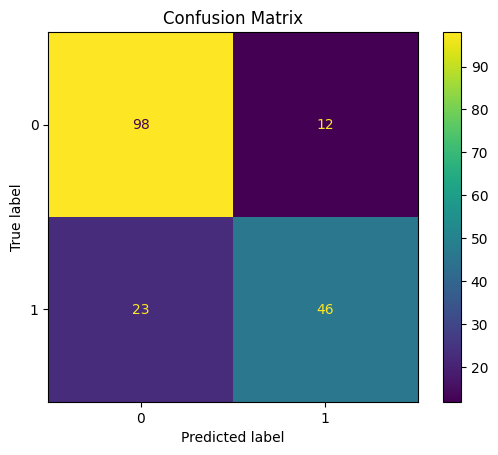

In [7]:
# classification report and confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

report = classification_report(y_test, y_pred)
print(report)

# plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = baseline_model.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [8]:
print("X columns:")
print(X.columns.tolist())

print("\ny shape:")
print(y.shape)

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

X columns:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

y shape:
(891,)

Numerical features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical features:
['Sex', 'Embarked']


### Interpretation from a baseline model without preprocessing

The baseline Logistic Regression model achieved an accuracy of 80%, suggesting that the demographic, socioeconomic, and family-related features included in the model contain useful information for predicting Titanic survival. The confusion matrix indicates that the model performed better at identifying passengers who did not survive, correctly classifying 98 of 110 non-survivors (89% recall), compared with correctly identifying 46 of 69 survivors (67% recall). This indicates that the model has greater difficulty identifying survivors. The difference in class-specific performance suggests that the relationships identified during EDA are useful for prediction but are not sufficient to perfectly distinguish survival outcomes.


### Intepretation from preprocessed model with pipeline

**The Pipeline-based Logistic Regression model produced the same test-set predictions and evaluation metrics as the earlier baseline model, indicating that the revised preprocessing workflow did not materially alter model performance.**

This doesn't mean the Pipeline was unnecessary. Quite the opposite: the Pipeline gives you a more robust and reproducible modeling workflow, because preprocessing is fitted within the training data rather than being handled separately.

**Baseline Model Findings**

The baseline Logistic Regression model achieved an accuracy of 80% on the test set, with a macro F1-score of 0.79. The confusion matrix showed that the model correctly classified 98 of the 110 passengers who did not survive and 46 of the 69 passengers who survived.

The model performed better at identifying non-survivors, achieving a recall of 89%, compared with 67% for survivors. This indicates that the model was more likely to correctly identify passengers who did not survive than those who survived. The survivor class also had a lower F1-score (0.72) compared with the non-survivor class (0.85), further demonstrating this difference in class-specific performance.

The Pipeline-based implementation produced the same predictions and evaluation metrics as the earlier Logistic Regression baseline. This suggests that incorporating imputation, scaling, and categorical encoding within a leakage-safe Pipeline did not materially change the model's predictive performance. The Pipeline nevertheless provides a more robust modeling workflow by ensuring that preprocessing steps are learned from the training data and consistently applied to the test data.

**Overall conclusion from the baseline**  

Overall, the baseline model provides a reasonable starting point, achieving approximately 80% accuracy, but its lower recall for survivors indicates an opportunity for improvement. Further experimentation with feature engineering and alternative classification algorithms can therefore be used to determine whether predictive performance can be improved beyond this baseline.

## Improving on the Baseline Model Using a Decision Tree

**Justification:**
- Logistic Regression assumes a relatively simple relationship between the predictors and the probability of survival.
- A Decision Tree can capture non-linear relationships and interactions.

**For example:** 
Survival might depend on combinations such as:
- Sex = female AND Pclass = 1

or

- Sex = male AND Pclass = 3 AND Fare = low

*A tree can naturally create these kinds of decision rules.*

In [ ]:
# model the tree
# reuse the pipeline from earlier
# only thing that changes is the classifier
